In [1]:
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd
import pickle

In [2]:
timepoints = pd.read_csv(f"data/preprocessed/timepoints.csv", index_col=0).iloc[:, 0]
celltypes = pd.read_csv(f"data/preprocessed/celltypes.csv", index_col=0).iloc[:, 0]

In [29]:
# with open("jobs/cfa_filtered_hsc_rnavar_variance_0.10_K_16_srand_42.pkl", "rb") as f:
with open("jobs/cfa_filtered_hsc_rnavar_variance_0.90_K_22_srand_42.pkl", "rb") as f:
    res = pickle.load(f)

In [30]:
res['fa_cons'].factors['Ve'].shape

(3123, 22)

In [36]:
res['fa_cons'].factors['Vm'].shape

(163, 22)

In [35]:
res['fa_cons'].activities.shape

(112, 22)

In [4]:
consensus_factors = res['fa_cons'].factors
cfm = res['cfm']

In [5]:
colors = {'cDC1' : '#E66100', 
         'Lymph' : '#1B9E77', 
         'Rest' : '#999999',
         'Mast' : '#8E44AD',
         'cDC2' : '#F1C40F', 
         'Ery' : '#D62728', 
         'pDC' : '#17BECF', 
         'Mye' : '#1F77B4'}

In [6]:
import matplotlib
cmaps = {name : matplotlib.colors.LinearSegmentedColormap.from_list(name, [(1, 1, 1), matplotlib.colors.hex2color(c)]) for (name, c) in colors.items()}

In [13]:
import numpy as np

def plot_multicolor(ax, data):
    vmax = data.max()
    for i, name in enumerate(celltypes):
        cmap = cmaps[name]
        masked_data = np.ma.masked_array(
            data, 
            mask=np.ones_like(data, dtype=bool)
        )
        masked_data.mask[i, :] = False  # Unmask only the current row
        im = ax.imshow(masked_data, cmap=cmap, aspect='auto', extent=[0, data.shape[1], data.shape[0], 0], vmin = 0, vmax = vmax)
    for i, name in enumerate(['Rest']):
        cmap = cmaps[name]
        # Create a scalar mappable with the colormap for the colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=matplotlib.colors.Normalize(vmin=0, vmax=vmax))
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, orientation='vertical')
        # cbar.ax.set_title(name)
        cbar.ax.set_title("Contribution")
        cbar.ax.set_ylim(0, vmax)

/tmp/ipykernel_210061/2694026598.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig=plt.figure(figsize = (4, 4))


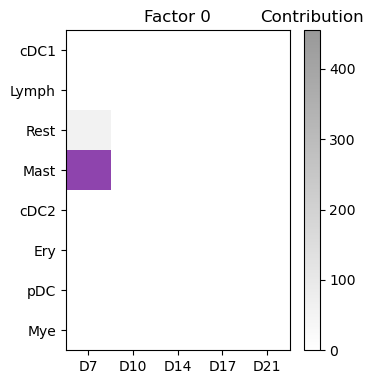

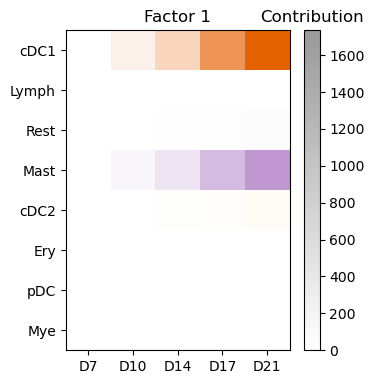

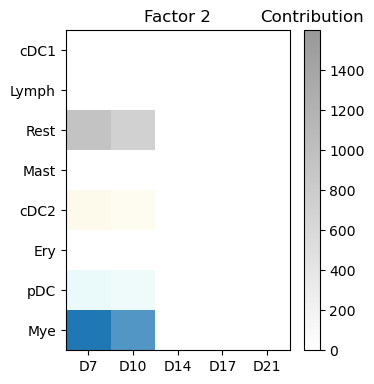

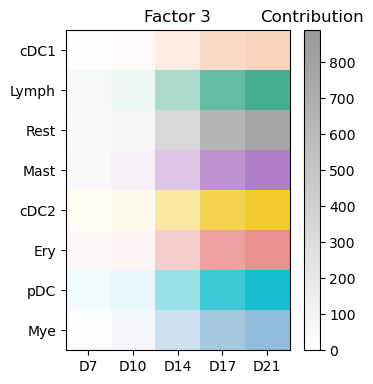

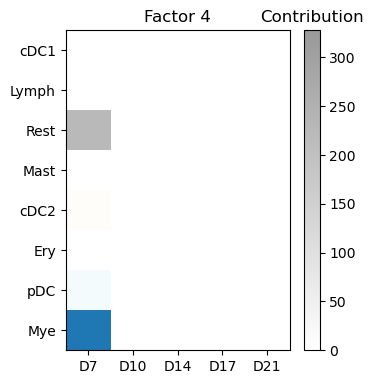

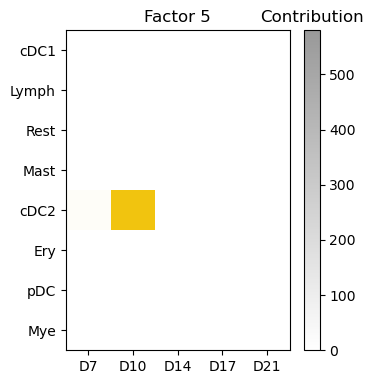

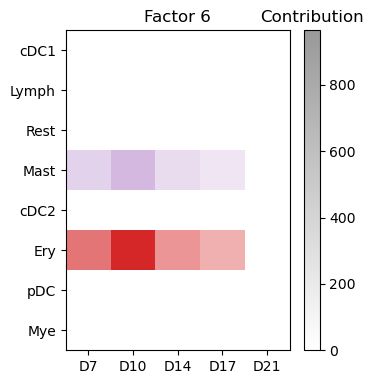

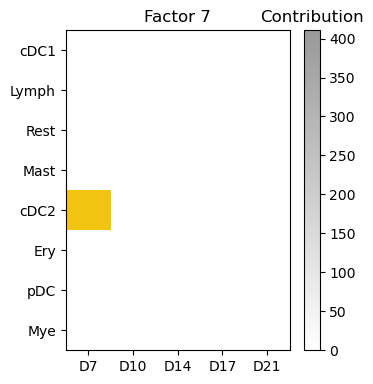

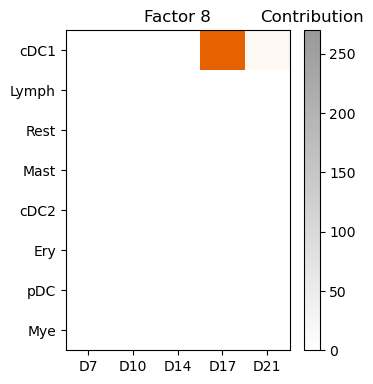

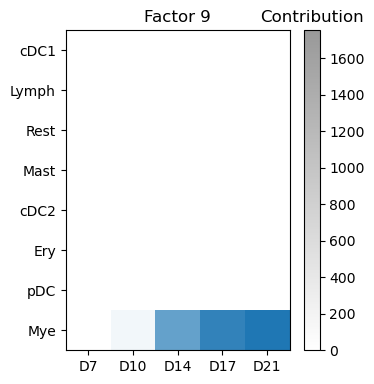

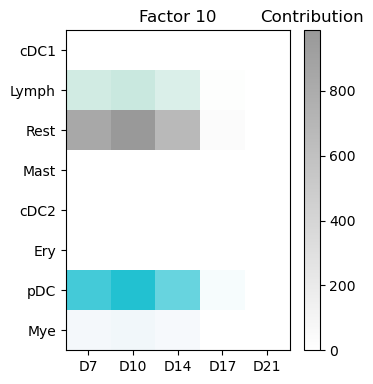

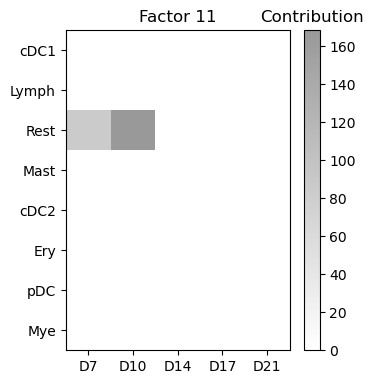

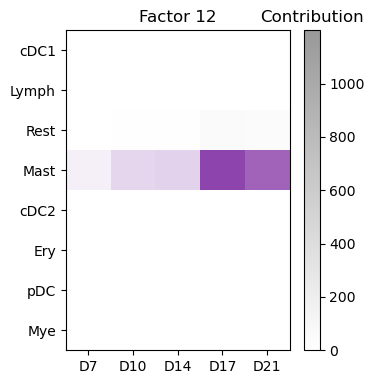

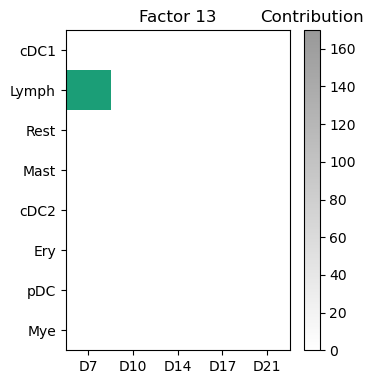

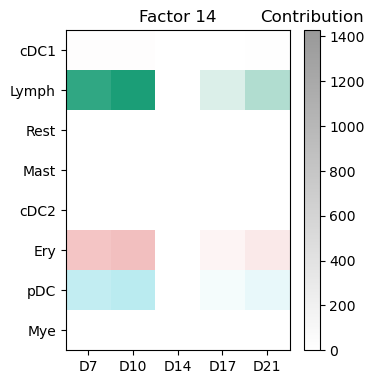

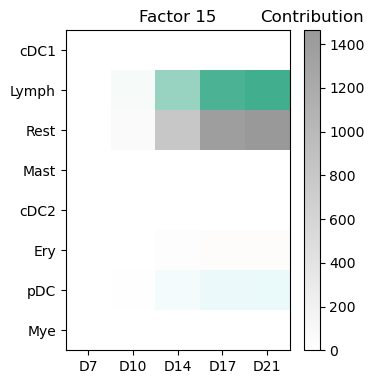

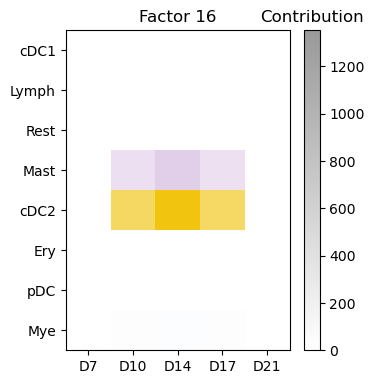

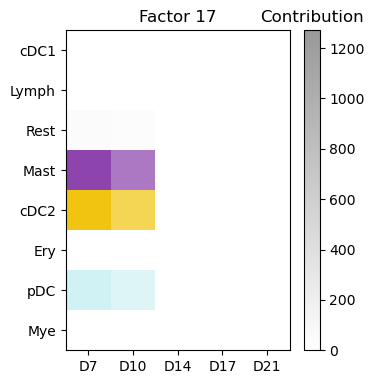

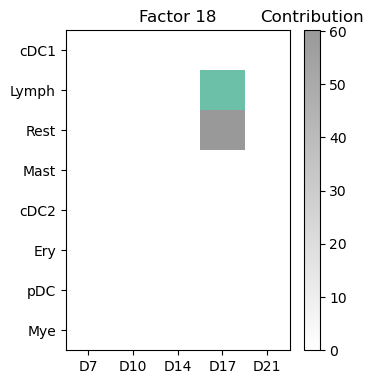

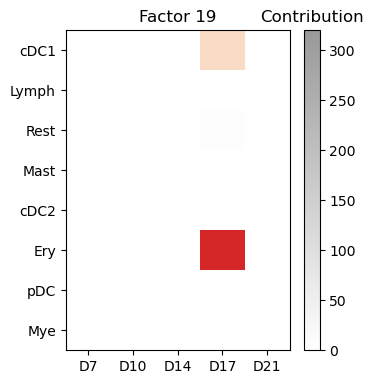

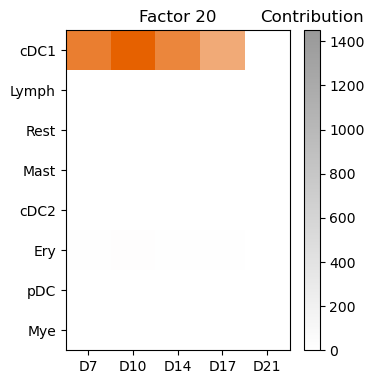

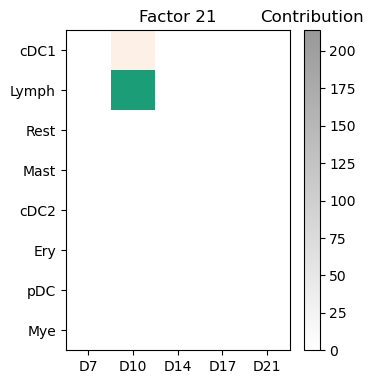

In [18]:
for i in range(cfm.k):
    fig=plt.figure(figsize = (4, 4))
    data = (consensus_factors["Vb_0"][:, i].reshape(-1, 1) @ consensus_factors["Vb_1"][:, i].reshape(1, -1)).T
    plot_multicolor(plt.gca(), data)
    plt.title(f"Factor {i}")
    plt.yticks(np.arange(len(celltypes))+1/2, celltypes)
    plt.xticks(np.arange(len(timepoints))+1/2, timepoints)
    plt.subplots_adjust(left=0.2, right=0.9, top=0.9, bottom=0.1)
    plt.savefig(f"figures_jul2025/factor_{i}.pdf")